In [13]:
import os
import ast
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/charts", exist_ok=True)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("当前目录：", os.getcwd())
print("torch 版本：", torch.__version__)
print("CUDA 是否可用：", torch.cuda.is_available())
print("使用设备：", device)

当前目录： /root/summer
torch 版本： 2.8.0+cu128
CUDA 是否可用： True
使用设备： cuda


In [14]:
df = pd.read_csv("data/processed_reviews.csv", encoding="utf-8-sig")

def parse_tokens(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    x = str(x)
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(i) for i in val]
    except:
        pass
    return x.split()

if "tokens_clean" in df.columns:
    df["tokens_list"] = df["tokens_clean"].apply(parse_tokens)
elif "tokens" in df.columns:
    df["tokens_list"] = df["tokens"].apply(parse_tokens)
elif "tokens_str" in df.columns:
    df["tokens_list"] = df["tokens_str"].fillna("").apply(lambda x: str(x).split())
else:
    raise ValueError("没有 tokens_clean / tokens / tokens_str，请先完成 v1。")

df["sentiment_v4"] = df["rating"].map(
    lambda x: "positive" if x >= 4 else ("negative" if x <= 2 else "neutral")
)

df_v4 = df[df["sentiment_v4"].isin(["positive", "negative"])].copy()
df_v4["label"] = (df_v4["sentiment_v4"] == "positive").astype(int)

df_v4 = df_v4[df_v4["tokens_list"].apply(len) > 0].reset_index(drop=True)

print("v4 二分类数据量：", len(df_v4))
print(df_v4["sentiment_v4"].value_counts())
print("正面占比：", df_v4["label"].mean())

df_v4[["review_text", "rating", "sentiment_v4", "tokens_list"]].head()

v4 二分类数据量： 42479
sentiment_v4
positive    32406
negative    10073
Name: count, dtype: int64
正面占比： 0.7628710657030533


,review_text,rating,sentiment_v4,tokens_list
0,下单半小时就到了，鸡腿堡还冒着热气，外酥里嫩。,4,positive,"[下单, 半小时, 鸡腿, 热气]"
1,食材不新鲜，烧鹅有一股怪味，味同嚼蜡，再也不来。,1,negative,"[食材, 新鲜, 烧鹅, 一股, 怪味, 味同嚼蜡, 再也]"
2,第一次点这家，烤翅惊艳到了，入口即化，五星好评！,4,positive,"[第一次, 这家, 惊艳, 入口, 五星, 好评]"
3,热干面分量少得可怜，价格还贵，令人作呕。,1,negative,"[热干面, 分量, 少得, 可怜, 价格, 还贵, 令人作呕]"
4,下单半小时就到了，石锅拌饭还冒着热气，鲜香可口。,5,positive,"[下单, 半小时, 石锅, 热气, 鲜香, 可口]"


In [15]:
MAX_VOCAB_SIZE = 5000
MAX_LEN = 50

counter = Counter()
for tokens in df_v4["tokens_list"]:
    counter.update(tokens)

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in most_common:
    word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}

def encode_tokens(tokens, max_len=MAX_LEN):
    ids = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [word2idx["<PAD>"]] * (max_len - len(ids))
    return ids

df_v4["input_ids"] = df_v4["tokens_list"].apply(encode_tokens)

print("词表大小：", len(word2idx))
print("序列长度：", MAX_LEN)
print(df_v4["input_ids"].iloc[0][:20])

词表大小： 271
序列长度： 50
[61, 62, 210, 63, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [18]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import torch

class ReviewDataset(Dataset):
    def __init__(self, input_ids, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.labels[idx]

indices = np.arange(len(df_v4))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=df_v4["label"]
)

train_inputs = df_v4.loc[train_idx, "input_ids"].tolist()
test_inputs = df_v4.loc[test_idx, "input_ids"].tolist()

train_labels = df_v4.loc[train_idx, "label"].tolist()
test_labels = df_v4.loc[test_idx, "label"].tolist()

BATCH_SIZE = 128

train_dataset = ReviewDataset(train_inputs, train_labels)
test_dataset = ReviewDataset(test_inputs, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("训练集：", len(train_dataset))
print("测试集：", len(test_dataset))
print("train_loader 创建完成")
print("test_loader 创建完成")

训练集： 33983
测试集： 8496
train_loader 创建完成
test_loader 创建完成


In [19]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=2, kernel_sizes=[2, 3, 4], num_filters=64, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x)              # batch, seq_len, embed_dim
        x = x.transpose(1, 2)              # batch, embed_dim, seq_len

        conv_outputs = []
        for conv in self.convs:
            out = torch.relu(conv(x))
            out = torch.max(out, dim=2)[0]
            conv_outputs.append(out)

        out = torch.cat(conv_outputs, dim=1)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits


class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, return_attention=False):
        mask = (x != 0)

        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)

        attn_scores = self.attention(lstm_out).squeeze(-1)
        attn_scores = attn_scores.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)

        context = self.dropout(context)
        logits = self.fc(context)

        if return_attention:
            return logits, attn_weights

        return logits

In [20]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return avg_loss, acc, f1


def train_model(model, model_name, epochs=3, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "train_f1": [],
        "test_f1": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_f1 = f1_score(all_labels, all_preds)

        test_loss, test_acc, test_f1 = evaluate_model(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_f1"].append(train_f1)
        history["test_f1"].append(test_f1)

        print(
            f"{model_name} | Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f} | "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, test_f1={test_f1:.4f}"
        )

    train_time = time.time() - start_time

    return model, history, train_time


def plot_training_curve(history, model_name, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 5),dpi=300)

    plt.plot(epochs, history["train_loss"], marker="o", label="training Loss")
    plt.plot(epochs, history["test_loss"], marker="o", label="test Loss")
    plt.plot(epochs, history["train_acc"], marker="s", label="training Accuracy")
    plt.plot(epochs, history["test_acc"], marker="s", label="test Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("value")
    plt.title(f"{model_name} training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [22]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import torch

class ReviewDataset(Dataset):
    def __init__(self, input_ids, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.labels[idx]

indices = np.arange(len(df_v4))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=df_v4["label"]
)

train_inputs = df_v4.loc[train_idx, "input_ids"].tolist()
test_inputs = df_v4.loc[test_idx, "input_ids"].tolist()

train_labels = df_v4.loc[train_idx, "label"].tolist()
test_labels = df_v4.loc[test_idx, "label"].tolist()

BATCH_SIZE = 128

train_dataset = ReviewDataset(train_inputs, train_labels)
test_dataset = ReviewDataset(test_inputs, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("训练集：", len(train_dataset))
print("测试集：", len(test_dataset))
print("train_loader 创建完成")
print("test_loader 创建完成")

训练集： 33983
测试集： 8496
train_loader 创建完成
test_loader 创建完成


TextCNN | Epoch 1/3 | train_loss=0.0254, train_acc=0.9897, train_f1=0.9933 | test_loss=0.0003, test_acc=1.0000, test_f1=1.0000
TextCNN | Epoch 2/3 | train_loss=0.0003, train_acc=1.0000, train_f1=1.0000 | test_loss=0.0001, test_acc=1.0000, test_f1=1.0000
TextCNN | Epoch 3/3 | train_loss=0.0001, train_acc=1.0000, train_f1=1.0000 | test_loss=0.0000, test_acc=1.0000, test_f1=1.0000


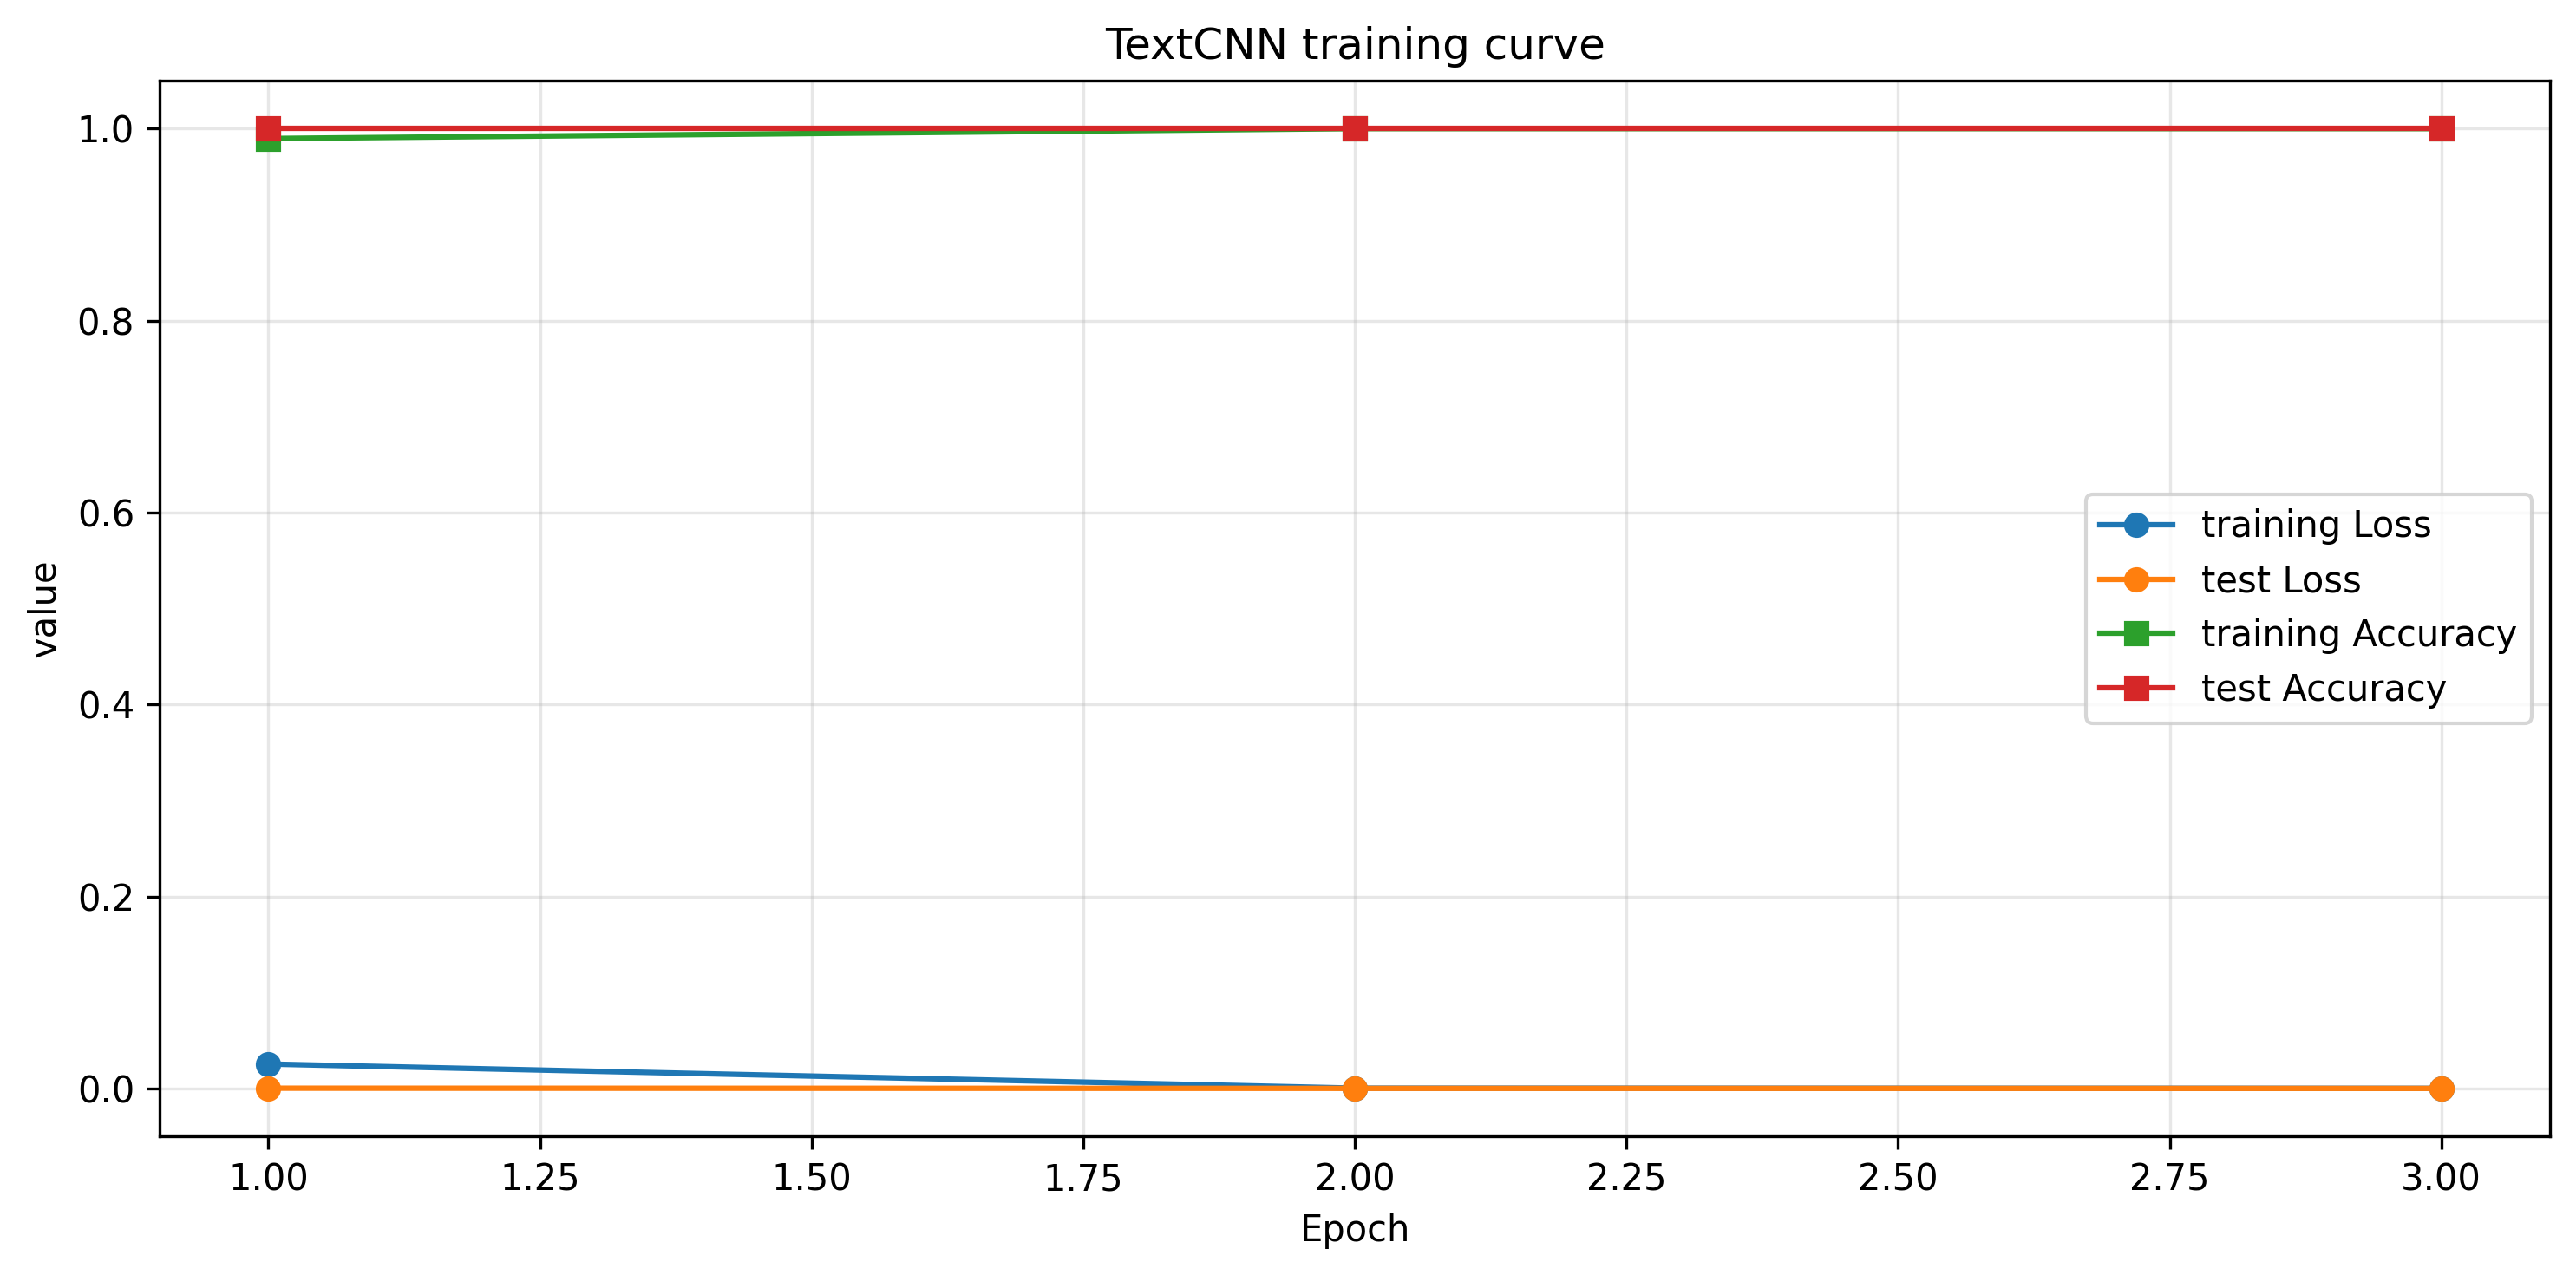

TextCNN 已保存：outputs/models/textcnn.pth


In [23]:
vocab_size = len(word2idx)

textcnn = TextCNN(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=2,
    kernel_sizes=[2, 3, 4],
    num_filters=64,
    dropout=0.5
)

textcnn, textcnn_history, textcnn_time = train_model(
    textcnn,
    model_name="TextCNN",
    epochs=3,
    lr=1e-3
)

plot_training_curve(
    textcnn_history,
    "TextCNN",
    "outputs/charts/textcnn_training.png"
)

torch.save({
    "model_state_dict": textcnn.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word,
    "max_len": MAX_LEN,
    "vocab_size": vocab_size
}, "outputs/models/textcnn.pth")

print("TextCNN 已保存：outputs/models/textcnn.pth")

Bi-LSTM+Attention | Epoch 1/3 | train_loss=0.0409, train_acc=0.9821, train_f1=0.9883 | test_loss=0.0001, test_acc=1.0000, test_f1=1.0000
Bi-LSTM+Attention | Epoch 2/3 | train_loss=0.0001, train_acc=1.0000, train_f1=1.0000 | test_loss=0.0000, test_acc=1.0000, test_f1=1.0000
Bi-LSTM+Attention | Epoch 3/3 | train_loss=0.0000, train_acc=1.0000, train_f1=1.0000 | test_loss=0.0000, test_acc=1.0000, test_f1=1.0000


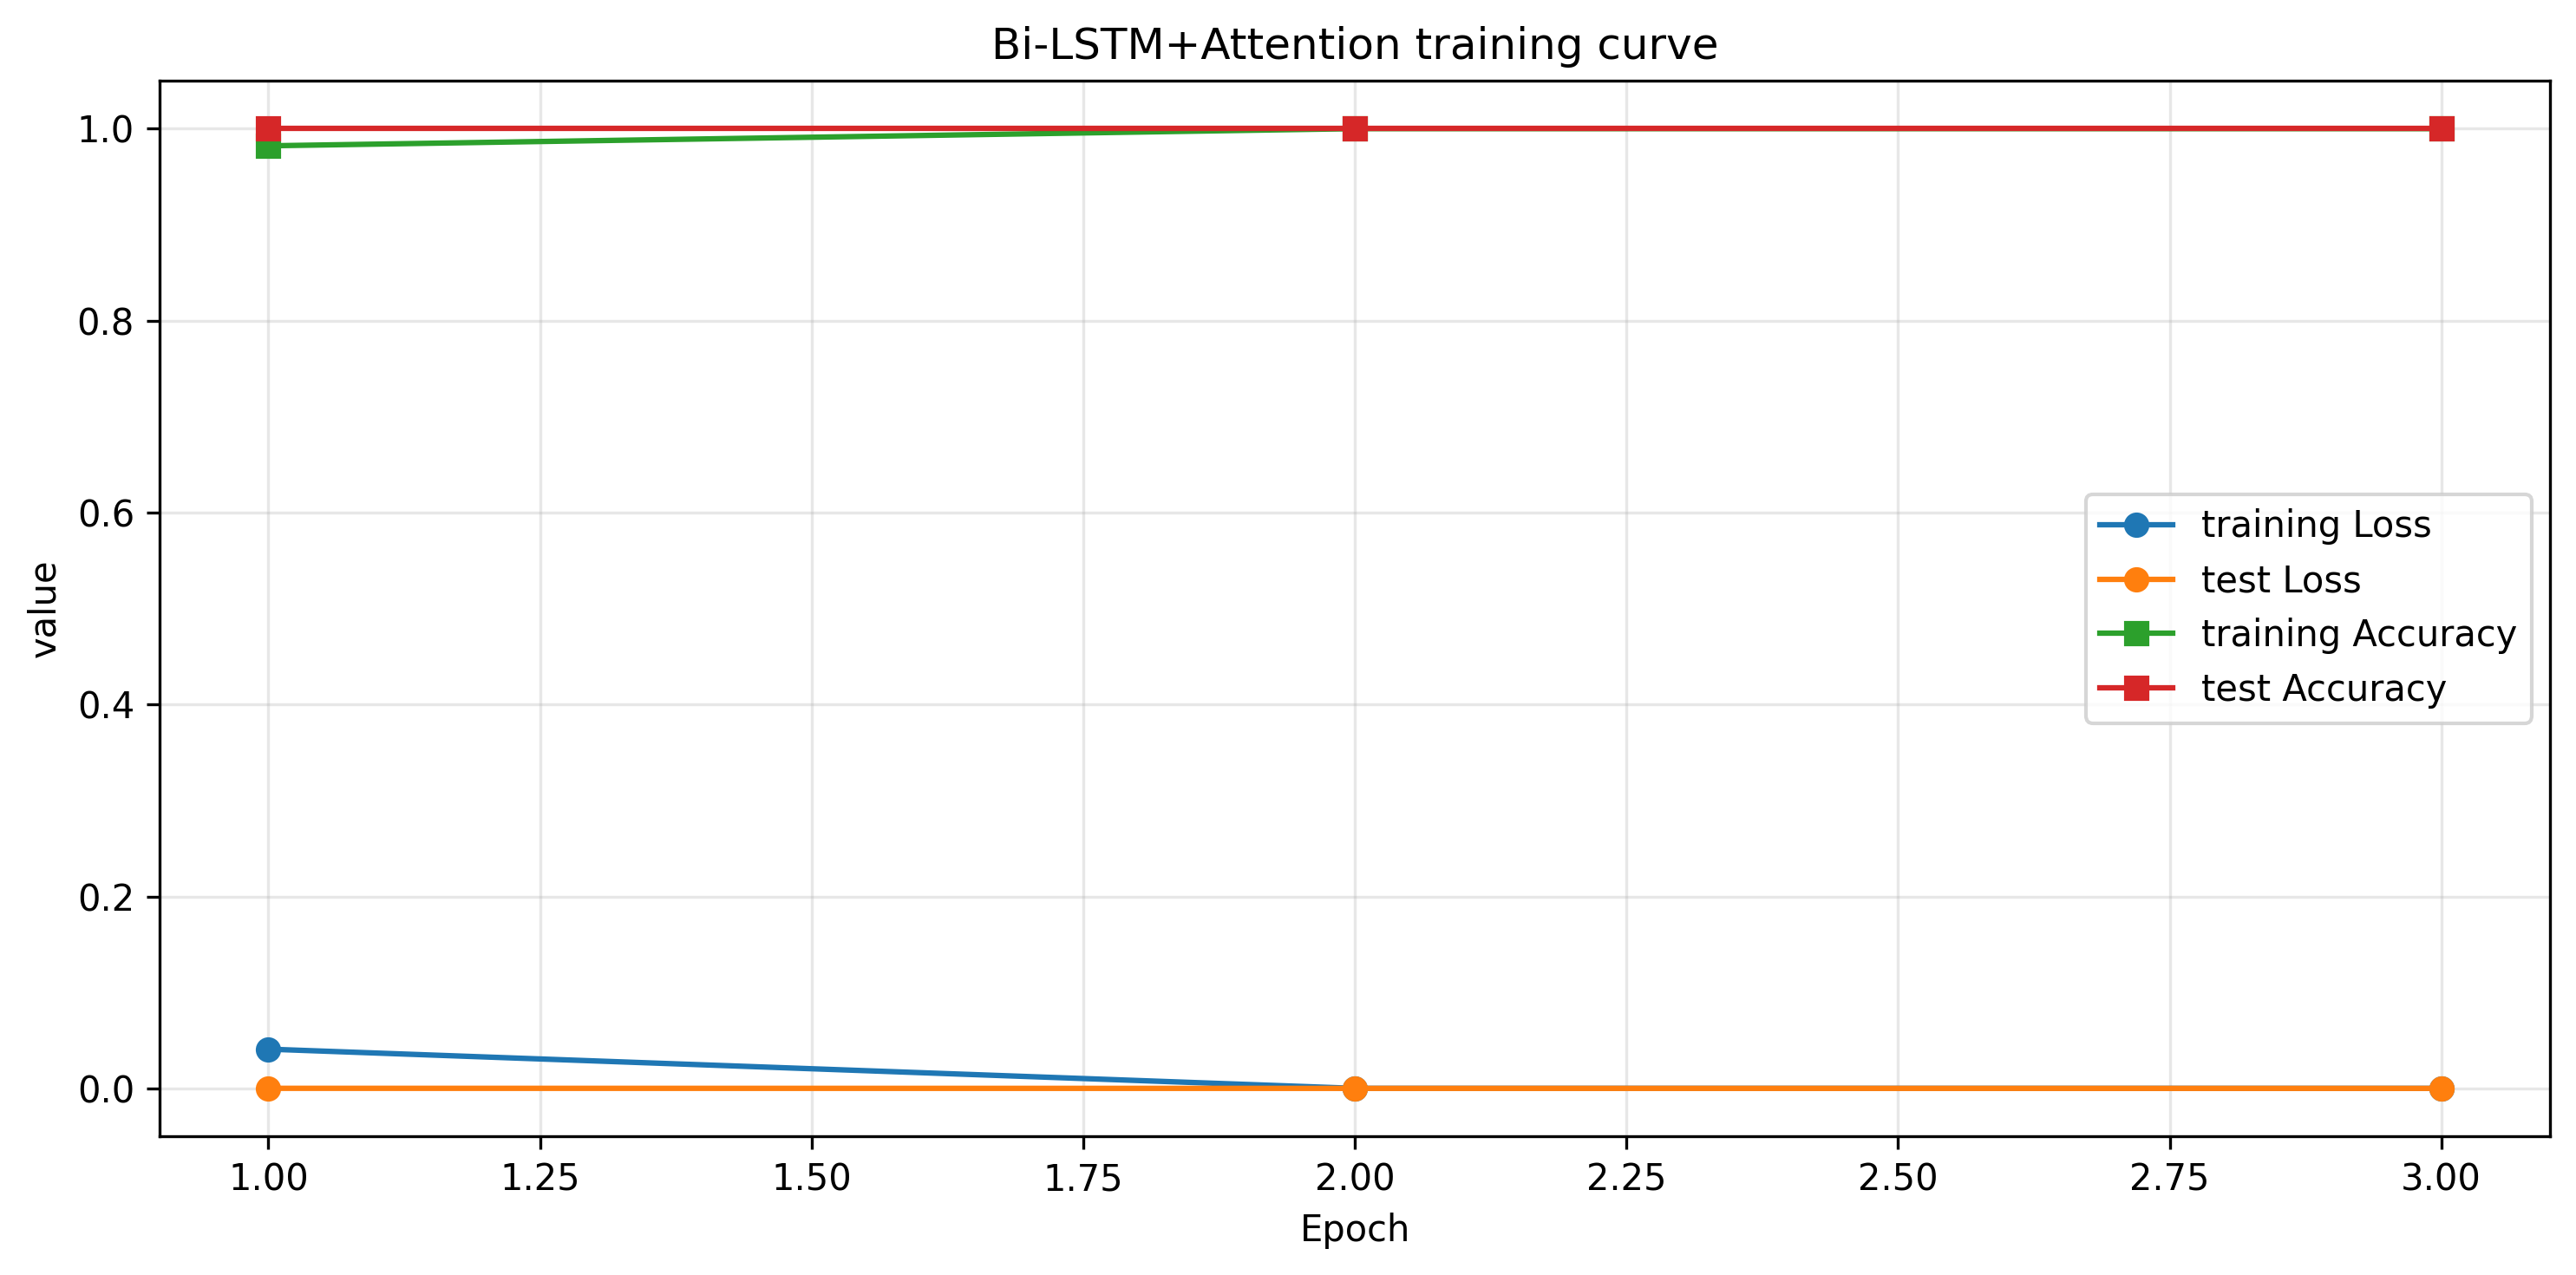

Bi-LSTM 已保存：outputs/models/bilstm.pth


In [26]:
bilstm = BiLSTMAttention(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=2,
    dropout=0.5
)

bilstm, bilstm_history, bilstm_time = train_model(
    bilstm,
    model_name="Bi-LSTM+Attention",
    epochs=3,
    lr=1e-3
)

plot_training_curve(
    bilstm_history,
    "Bi-LSTM+Attention",
    "outputs/charts/bilstm_training.png"
)

torch.save({
    "model_state_dict": bilstm.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word,
    "max_len": MAX_LEN,
    "vocab_size": vocab_size
}, "outputs/models/bilstm.pth")

print("Bi-LSTM 已保存：outputs/models/bilstm.pth")

In [27]:
def get_predictions(model, data_loader):
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y_batch.numpy())

    return np.array(labels_all), np.array(preds_all)

y_true_textcnn, y_pred_textcnn = get_predictions(textcnn, test_loader)
y_true_bilstm, y_pred_bilstm = get_predictions(bilstm, test_loader)

print("TextCNN 分类报告：")
print(classification_report(y_true_textcnn, y_pred_textcnn, target_names=["负面", "正面"], digits=4))

print("\nBi-LSTM+Attention 分类报告：")
print(classification_report(y_true_bilstm, y_pred_bilstm, target_names=["负面", "正面"], digits=4))

TextCNN 分类报告：
              precision    recall  f1-score   support

          负面     1.0000    1.0000    1.0000      2015
          正面     1.0000    1.0000    1.0000      6481

    accuracy                         1.0000      8496
   macro avg     1.0000    1.0000    1.0000      8496
weighted avg     1.0000    1.0000    1.0000      8496


Bi-LSTM+Attention 分类报告：
              precision    recall  f1-score   support

          负面     1.0000    1.0000    1.0000      2015
          正面     1.0000    1.0000    1.0000      6481

    accuracy                         1.0000      8496
   macro avg     1.0000    1.0000    1.0000      8496
weighted avg     1.0000    1.0000    1.0000      8496



original comments： 点了寿司拼盘结果送错了，客服也不处理，腥气熏天。包装很结实。
real tags： negative
predicted tags： negative

words with highest attentions：


,token,attention
5,处理,0.252237
6,腥气,0.187652
4,客服,0.160784
7,熏天,0.158015
3,送错,0.055488
9,结实,0.050864
8,包装,0.044404
2,结果,0.040443
1,拼盘,0.027558
0,寿司,0.022554


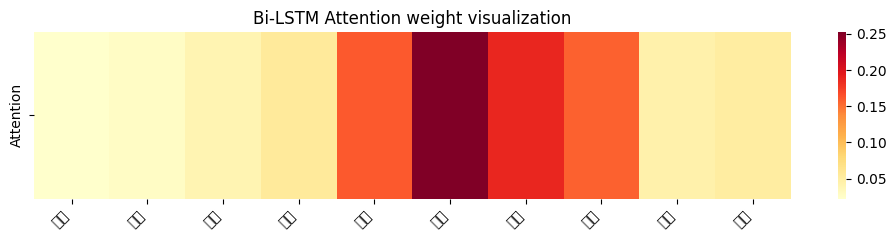

In [29]:
import seaborn as sns

# 选一条测试集评论
sample_i = 0
sample_row = df_v4.iloc[test_idx[sample_i]]
sample_ids = torch.tensor([sample_row["input_ids"]], dtype=torch.long).to(device)

bilstm.eval()
with torch.no_grad():
    logits, attn_weights = bilstm(sample_ids, return_attention=True)
    pred = torch.argmax(logits, dim=1).item()

tokens = sample_row["tokens_list"][:MAX_LEN]
weights = attn_weights[0][:len(tokens)].detach().cpu().numpy()

attn_df = pd.DataFrame({
    "token": tokens,
    "attention": weights
}).sort_values("attention", ascending=False)

print("original comments：", sample_row["review_text"])
print("real tags：", "positive" if sample_row["label"] == 1 else "negative")
print("predicted tags：", "positive" if pred == 1 else "negative")
print("\nwords with highest attentions：")
display(attn_df.head(10))

plt.figure(figsize=(max(10, len(tokens) * 0.35), 2.5))
sns.heatmap(
    [weights],
    xticklabels=tokens,
    yticklabels=["Attention"],
    cmap="YlOrRd",
    cbar=True
)
plt.xticks(rotation=45, ha="right")
plt.title("Bi-LSTM Attention weight visualization")
plt.tight_layout()
plt.savefig("outputs/charts/attention_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

,模型,Accuracy,F1,训练时间_秒
0,NB_朴素贝叶斯,1.00000,1.000,0.009497
1,LR_逻辑回归,1.00000,1.000,0.158756
2,LinearSVM_线性支持向量机,1.00000,1.000,0.054385
3,SGD_线性分类器,1.00000,1.000,0.020998
4,RF_随机森林,0.99541,0.997,0.513600
5,TextCNN,1.00000,1.000,5.674363
6,Bi-LSTM+Attention,1.00000,1.000,7.696509


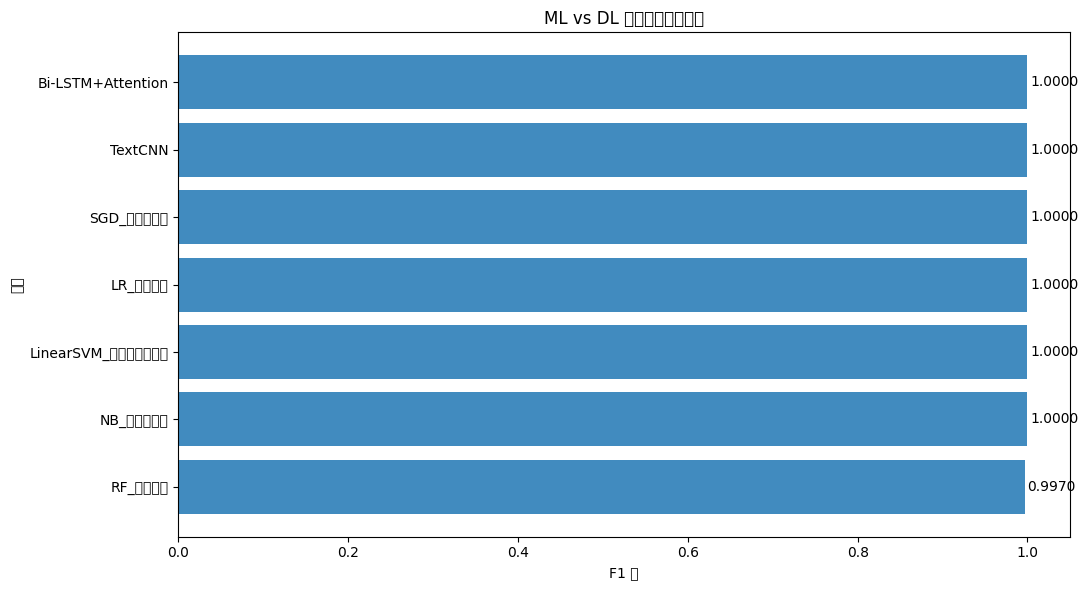

In [30]:
dl_results = pd.DataFrame([
    {
        "模型": "TextCNN",
        "Accuracy": textcnn_history["test_acc"][-1],
        "F1": textcnn_history["test_f1"][-1],
        "训练时间_秒": textcnn_time
    },
    {
        "模型": "Bi-LSTM+Attention",
        "Accuracy": bilstm_history["test_acc"][-1],
        "F1": bilstm_history["test_f1"][-1],
        "训练时间_秒": bilstm_time
    }
])

ml_path = "outputs/models/model_results.csv"

if os.path.exists(ml_path):
    ml_results = pd.read_csv(ml_path, encoding="utf-8-sig")
    keep_cols = ["模型", "Accuracy", "F1", "训练时间_秒"]
    ml_results = ml_results[[c for c in keep_cols if c in ml_results.columns]].copy()
    compare_df = pd.concat([ml_results, dl_results], ignore_index=True)
else:
    compare_df = dl_results.copy()

compare_df.to_csv("outputs/models/ml_vs_dl_results.csv", index=False, encoding="utf-8-sig")

display(compare_df)

plt.figure(figsize=(11, 6))
plot_df = compare_df.sort_values("F1", ascending=True)

plt.barh(plot_df["模型"], plot_df["F1"], alpha=0.85)

for i, v in enumerate(plot_df["F1"]):
    plt.text(v + 0.003, i, f"{v:.4f}", va="center")

plt.xlabel("F1 值")
plt.ylabel("模型")
plt.title("ML vs DL 情感分类性能对比")
plt.xlim(0, min(1.05, plot_df["F1"].max() + 0.08))
plt.tight_layout()
plt.savefig("outputs/charts/ml_vs_dl.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
required_v4_files = [
    "outputs/models/textcnn.pth",
    "outputs/models/bilstm.pth",
    "outputs/models/ml_vs_dl_results.csv",
    "outputs/charts/textcnn_training.png",
    "outputs/charts/bilstm_training.png",
    "outputs/charts/attention_visualization.png",
    "outputs/charts/ml_vs_dl.png"
]

for path in required_v4_files:
    print(path, "存在" if os.path.exists(path) else "缺失")

outputs/models/textcnn.pth 存在
outputs/models/bilstm.pth 存在
outputs/models/ml_vs_dl_results.csv 存在
outputs/charts/textcnn_training.png 存在
outputs/charts/bilstm_training.png 存在
outputs/charts/attention_visualization.png 存在
outputs/charts/ml_vs_dl.png 存在
